In [2]:
!pip install torchmetrics
!pip install segmentation_models_pytorch
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 926.4/926.4 kB 23.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 13.2 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16424 sha256=cb81f696331408f181f07c0b6efcc7425651b6b322fe6e83c5a42d3a8619e3a6
  Stored in directory: /root/.cache/pip/wheels/03/3f/e9/911b1bc46869644912bda90a56bcf7b960f20b5187feea3baf
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60944 sha256=5ff8cd08c5673496f1e8a7afd90eaa6124534ab5df545d583d1ecce5d3972055
  Stored in directory: /root/.cache/pip/wheels/35/cb/a5/8f534c601

In [3]:
import zipfile
from google.colab import drive
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from sklearn.model_selection import train_test_split
import os
import albumentations as A
import numpy as np
from albumentations.pytorch import ToTensorV2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.utils import save_image
from segmentation_models_pytorch.losses import DiceLoss
import segmentation_models_pytorch as smp

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.22 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
drive.mount('/content/drive')

zipped_train = '/content/drive/MyDrive/для кодов/рак/data.zip'
z = zipfile.ZipFile(zipped_train, 'r')
z.extractall(path='/content/train')

zipped_test = '/content/drive/MyDrive/для кодов/рак/data.zip'
z = zipfile.ZipFile(zipped_test, 'r')
z.extractall(path='/content/test')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import gc
gc.collect()


16

In [7]:
transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Dataset
class SkinCancerDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.images_dir = os.path.join(data_dir, "images")
        self.masks_dir = os.path.join(data_dir, "masks")
        self.id = [os.path.splitext(file)[0] for file in os.listdir(self.images_dir)
                   if os.path.exists(os.path.join(self.masks_dir, os.path.splitext(file)[0] + '.png'))]

    def __len__(self):
        return len(self.id)

    def __getitem__(self, idx):
        image_id = self.id[idx]
        image_path = os.path.join(self.images_dir, image_id + '.jpg')
        mask_path = os.path.join(self.masks_dir, image_id + '.png')
        img = Image.open(image_path)
        mask = Image.open(mask_path)
        img = np.array(img)
        mask = np.array(mask)
        mask[mask == 255.0] = 1.0

        if self.transform:
            augmentation = self.transform(image=img, mask=mask)
            img = augmentation["image"]
            mask = augmentation["mask"]
            mask = torch.unsqueeze(mask, 0)

        return img, mask

# Split dataset

train_dir = '/content/train'  # Path to the extracted data directory
dataset = SkinCancerDataset(train_dir, transform=transform)
train_dataset, valid_dataset = train_test_split(dataset, test_size=0.1)


In [ ]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from segmentation_models_pytorch import Unet
import segmentation_models_pytorch as smp
from torch import optim
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch.utils.metrics import IoU

# Путь к вашим данным
images_dir = '/content/drive/MyDrive/для кодов/рак/images'
masks_dir = '/content/drive/MyDrive/для кодов/рак/masks'

# Функция для выравнивания количества изображений и масок
def align_files(images_dir, masks_dir):
    # Получаем списки файлов в обеих папках
    image_files = sorted(os.listdir(images_dir))
    mask_files = sorted(os.listdir(masks_dir))

    # Проверяем, чтобы файлы имели одинаковое количество
    min_len = min(len(image_files), len(mask_files))

    # Оставляем только те файлы, которые есть в обеих папках
    aligned_image_files = image_files[:min_len]
    aligned_mask_files = mask_files[:min_len]

    return aligned_image_files, aligned_mask_files

# Получаем выровненные файлы
aligned_image_files, aligned_mask_files = align_files(images_dir, masks_dir)

# Custom Dataset
class CustomDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_files, mask_files, transform=None):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_files = image_files
        self.mask_files = mask_files
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # Загрузка изображения и маски
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        mask_path = os.path.join(self.masks_dir, self.mask_files[idx])

        image = Image.open(image_path).convert('RGB')  # Загружаем изображение
        mask = Image.open(mask_path).convert('L')  # Преобразуем маску в grayscale

        # Convert PIL Image to NumPy array before applying transforms
        image = np.array(image)
        mask = np.array(mask)

        if self.transform:
            # Apply the transform to both image and mask
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        else:
            # Apply a default transform if none is provided
            image = transforms.ToTensor()(image)
            mask = transforms.ToTensor()(mask)

        return image, mask

transform = A.Compose([
    A.Resize(256, 256),  # Resize to a size divisible by 32
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# Pass the transform to your dataset
train_dataset = CustomDataset(images_dir, masks_dir, aligned_image_files, aligned_mask_files, transform=transform) # Ensure transform is passed here

# Подготовка модели
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

# DataLoader
bs = 32
#train_dataset = CustomDataset(images_dir, masks_dir, aligned_image_files, aligned_mask_files)  # Remove this line, it was overwriting the previous train_dataset
train_dataloader = DataLoader(dataset=train_dataset, batch_size=bs, shuffle=True)

# Loss and optimizer
lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = DiceLoss(mode='binary')

# Training loop
epochs = 5
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Для сохранения лучшей модели
best_accuracy = 0
def save_model_to_drive(model, name):
    pth = os.path.join('/content/drive/MyDrive/Colab Notebooks/models', name)
    torch.save(model, pth)

# IoU для метрики
metric = IoU(threshold=0.5)

# Тренировка
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for idx, (image, mask) in enumerate(train_dataloader):
        image = image.float().to(device)
        mask = mask.float().to(device)

        optimizer.zero_grad()

        output = model(image)
        loss = criterion(output, mask)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)

    # Валидация
    model.eval()
    total_val_loss = 0.0
    total_val_iou = 0.0
    with torch.no_grad():
        for idx, (image, mask) in enumerate(train_dataloader):  # Для упрощения использую train_dataloader вместо val_dataloader
            image = image.float().to(device)
            mask = mask.float().to(device)
            output = model(image)
            loss = criterion(output, mask)
            total_val_loss += loss.item()
            total_val_iou += metric(output, mask).item()

        avg_val_loss = total_val_loss / len(train_dataloader)
        avg_val_iou = total_val_iou / len(train_dataloader)

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val IoU: {avg_val_iou:.4f}")

    # Проверяем точность и сохраняем модель
    accuracy = avg_val_iou  # Используем метрику IoU для точности
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        save_model_to_drive(model, f'resnet34_epoch_{epoch+1}.pth')
        print('Model saved!')


Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 195MB/s]


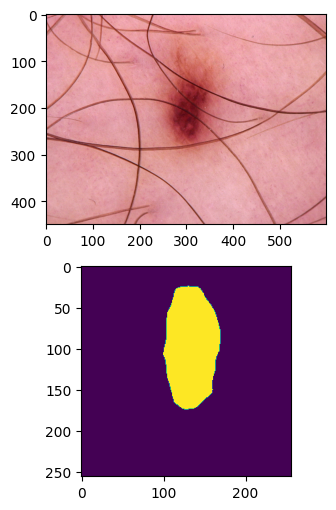

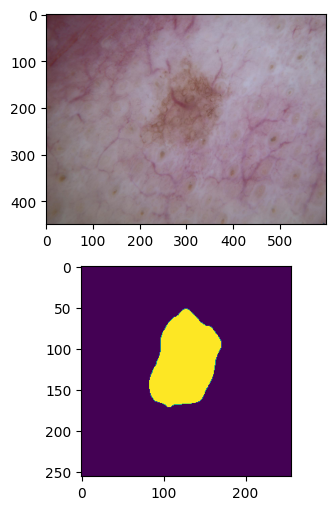

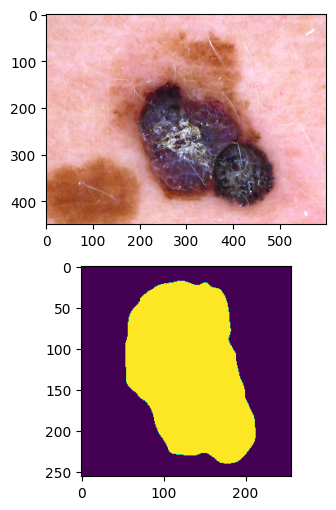

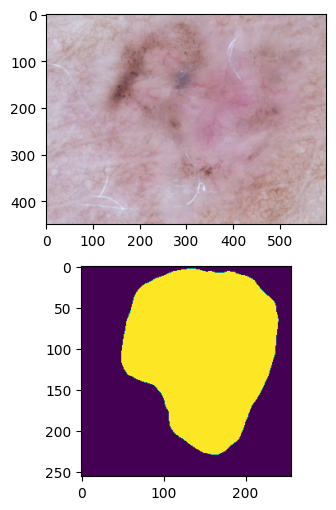

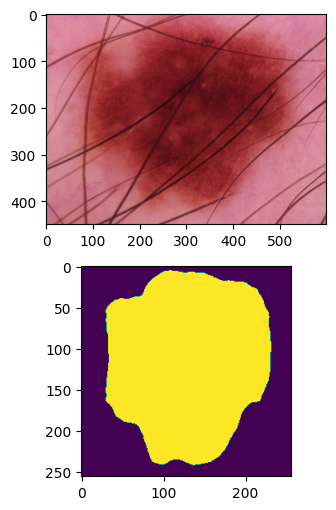

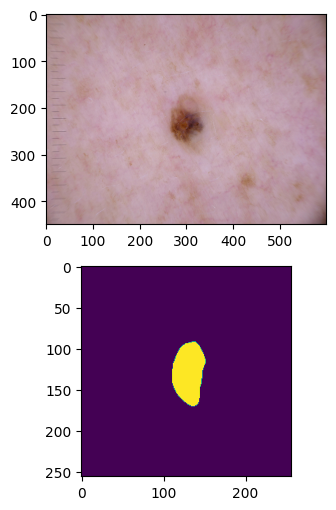

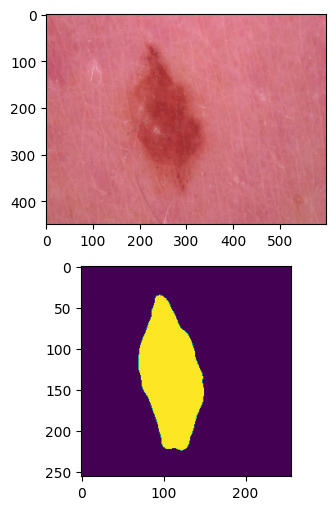

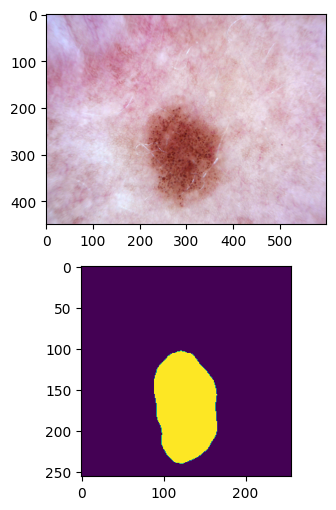

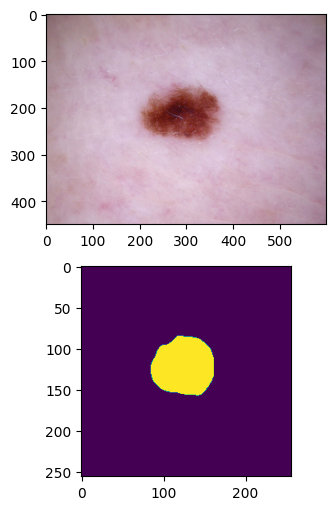

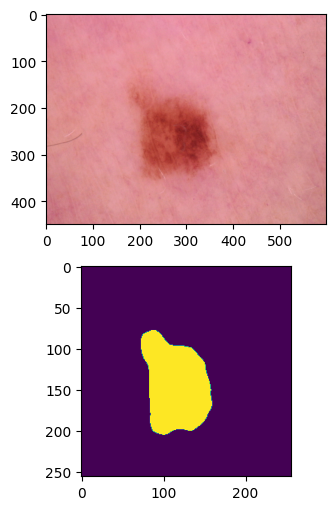

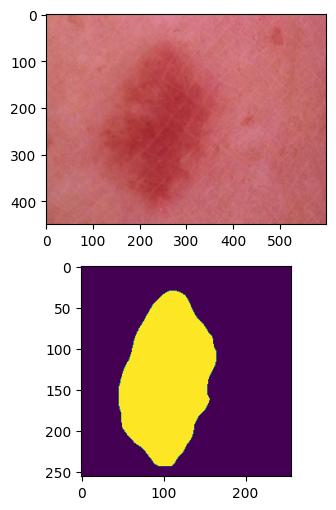

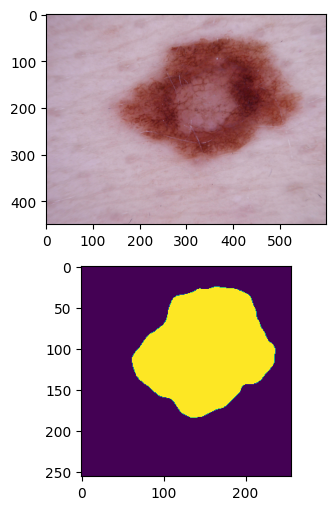

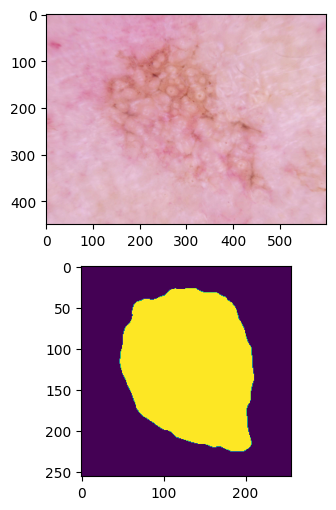

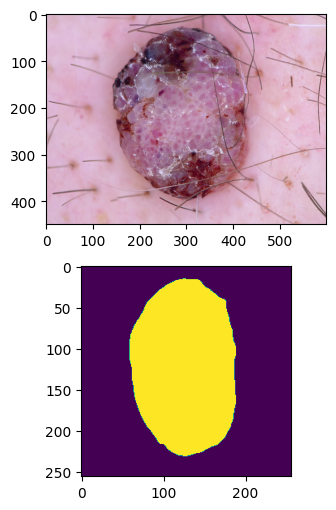

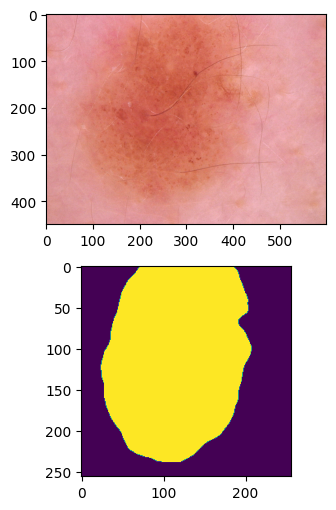

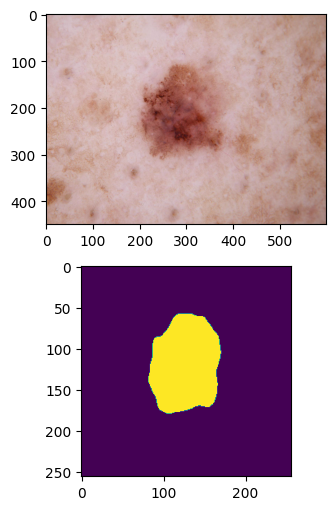

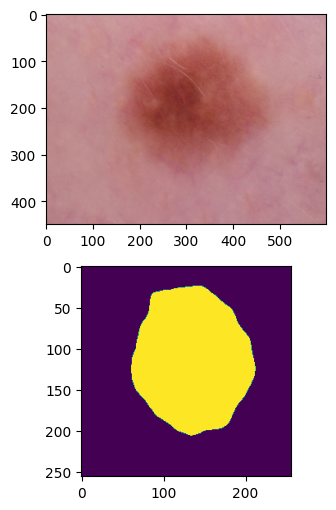

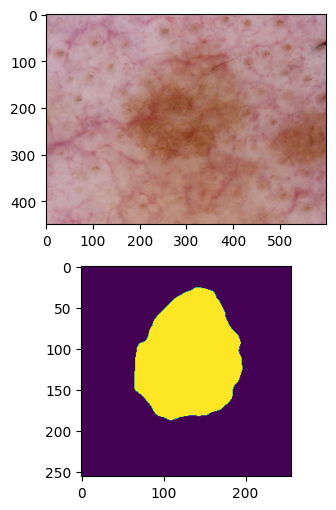

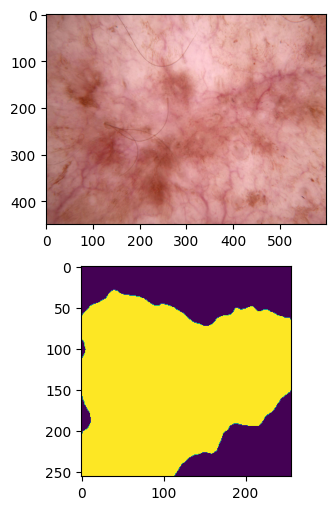

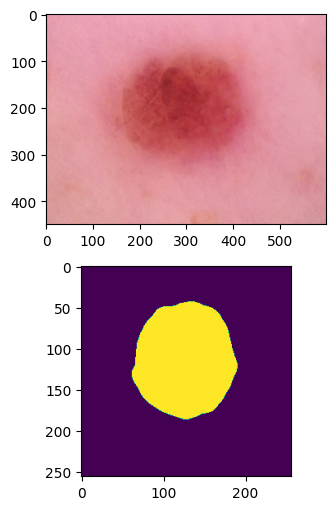

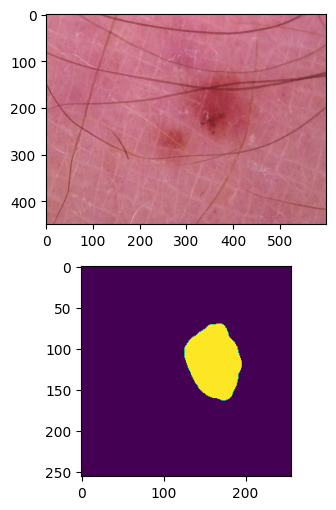

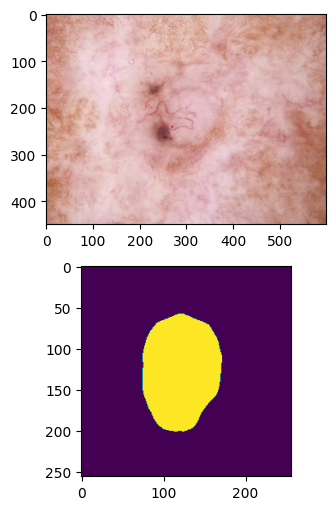

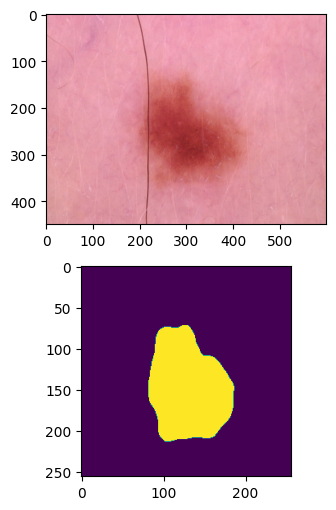

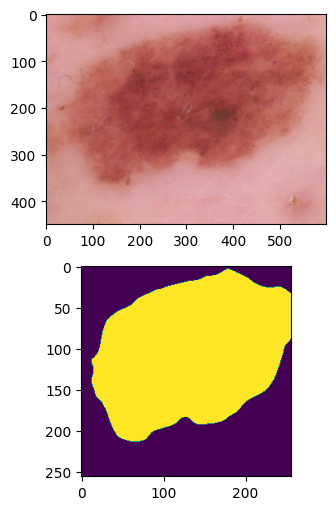

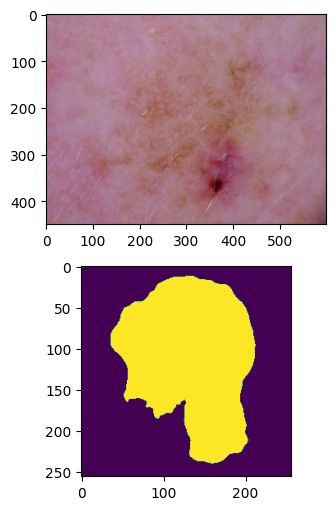

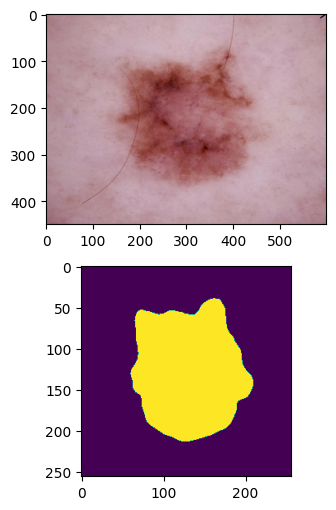

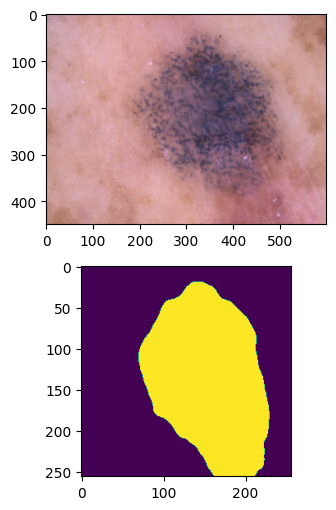

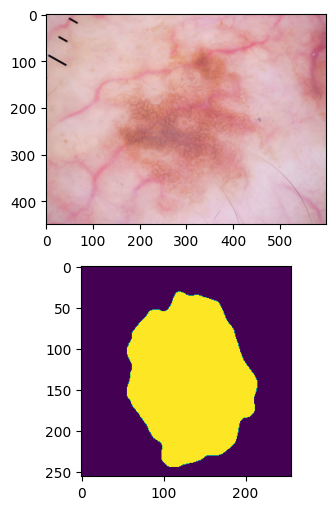

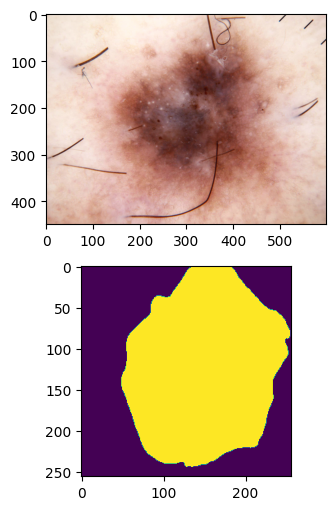

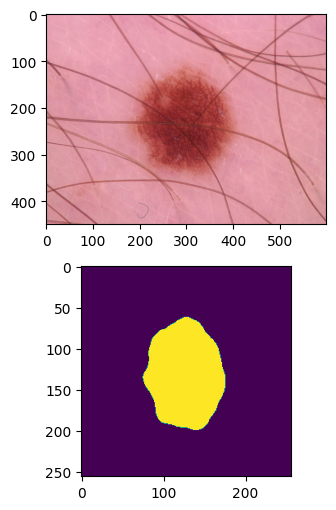

In [ ]:
from PIL import Image
from torchvision.transforms.functional import to_pil_image
import torch
import matplotlib.pyplot as plt

# Test directory
test_dir = "/content/test/"
images_dir = os.path.join(test_dir, "images")
masks_dir = os.path.join(test_dir, "masks")

# Create masks directory if not exists
os.makedirs(masks_dir, exist_ok=True)

# Transformation
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Get list of image filenames
image_filenames = os.listdir(images_dir)

# Process images and save masks
with torch.no_grad():
    for image_filename in image_filenames:
        # Load and preprocess image
        image_path = os.path.join(images_dir, image_filename)
        img = Image.open(image_path).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

        # Generate predicted mask
        predicted_mask = model(img)
        predicted_mask = torch.sigmoid(predicted_mask)
        predicted_mask = (predicted_mask > 0.5).float()
        predicted_mask = to_pil_image(predicted_mask.squeeze().cpu())

        # Save predicted mask
        mask_filename = os.path.splitext(image_filename)[0] + '.png'
        mask_path = os.path.join(masks_dir, mask_filename)
        predicted_mask.save(mask_path)

# Display a subset of images with their masks
valid_image_files = [file for file in image_filenames
                     if os.path.exists(os.path.join(masks_dir, os.path.splitext(file)[0] + '.png'))]

selected_images = valid_image_files[:30]

for image_filename in selected_images:
    # Load image and mask
    image_path = os.path.join(images_dir, image_filename)
    mask_path = os.path.join(masks_dir, os.path.splitext(image_filename)[0] + '.png')
    image = plt.imread(image_path)
    mask = plt.imread(mask_path)

    # Display images and masks
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))
    ax1.imshow(image)
    ax2.imshow(mask)
    plt.show()

In [ ]:
!zip -r '/content/masks.zip' '/content/test/masks'

  adding: content/test/masks/ (stored 0%)
  adding: content/test/masks/ISIC_0028842.png (deflated 1%)
  adding: content/test/masks/ISIC_0025157.png (deflated 2%)
  adding: content/test/masks/ISIC_0032581.png (deflated 2%)
  adding: content/test/masks/ISIC_0033047.png (deflated 1%)
  adding: content/test/masks/ISIC_0025854.png (deflated 2%)
  adding: content/test/masks/ISIC_0026980.png (deflated 1%)
  adding: content/test/masks/ISIC_0029072.png (deflated 10%)
  adding: content/test/masks/ISIC_0031694.png (deflated 4%)
  adding: content/test/masks/ISIC_0029156.png (deflated 2%)
  adding: content/test/masks/ISIC_0029908.png (deflated 3%)
  adding: content/test/masks/ISIC_0029277.png (deflated 2%)
  adding: content/test/masks/ISIC_0032658.png (deflated 1%)
  adding: content/test/masks/ISIC_0033324.png (deflated 2%)
  adding: content/test/masks/ISIC_0028414.png (stored 0%)
  adding: content/test/masks/ISIC_0025113.png (deflated 1%)
  adding: content/test/masks/ISIC_0028480.png (deflated 6%)